[20.64502087 23.4308709  25.25500841 27.27411397 29.3674293  30.09783311
 30.05895223 30.0303707  28.75464015 27.20463613 25.39784311 22.39997787
 19.93323896 17.75878041 15.27232485 13.65134776 11.73535593 10.61013481
 11.1413287  10.96609303 12.02802162 13.1296491  15.41285937 17.96074345
 19.49033252 22.22687576 24.59755699 27.44936678 28.51300214 29.22022981
 30.1323773  29.17128999 28.57971039 26.30578229 24.37961316 22.37344226
 19.8920641  17.07807485 14.52828479 12.35703382 10.38044034  9.5875519
  9.31724279 10.12064183 10.92708243 11.91845288 14.66020446 16.91113968
 20.28381034 23.03835148 25.37073744 27.23566253 28.15847582 29.23147644
 29.73536725 29.6169037  28.2664888  26.90058081 24.72953709 22.49598661
 20.73064468 18.52579729 15.89073326 14.31855524 12.67202361 11.45599779
 11.44620433 12.11094469 12.55278499 14.48688847 15.12641276 18.36549603
 19.63400555 21.86071854 24.16083879 25.41152986 27.38024571 28.45746362
 29.10209789 28.19484878 27.2035992  25.85727342 24.

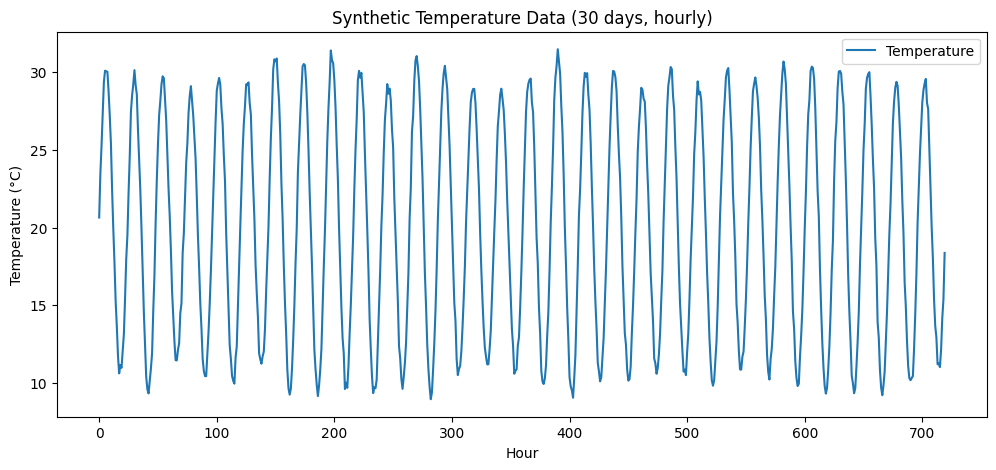

Epoch [1/10000], Loss: 464.2867
Epoch [2/10000], Loss: 458.4439
Epoch [3/10000], Loss: 452.5680
Epoch [4/10000], Loss: 446.6870
Epoch [5/10000], Loss: 440.8327
Epoch [6/10000], Loss: 435.0340
Epoch [7/10000], Loss: 429.3166
Epoch [8/10000], Loss: 423.7057
Epoch [9/10000], Loss: 418.2262
Epoch [10/10000], Loss: 412.9016
Epoch [11/10000], Loss: 407.7519
Epoch [12/10000], Loss: 402.7922
Epoch [13/10000], Loss: 398.0333
Epoch [14/10000], Loss: 393.4813
Epoch [15/10000], Loss: 389.1393
Epoch [16/10000], Loss: 385.0072
Epoch [17/10000], Loss: 381.0827
Epoch [18/10000], Loss: 377.3612
Epoch [19/10000], Loss: 373.8355
Epoch [20/10000], Loss: 370.4969
Epoch [21/10000], Loss: 367.3345
Epoch [22/10000], Loss: 364.3369
Epoch [23/10000], Loss: 361.4920
Epoch [24/10000], Loss: 358.7883
Epoch [25/10000], Loss: 356.2145
Epoch [26/10000], Loss: 353.7602
Epoch [27/10000], Loss: 351.4154
Epoch [28/10000], Loss: 349.1706
Epoch [29/10000], Loss: 347.0172
Epoch [30/10000], Loss: 344.9468
Epoch [31/10000], L

In [ ]:
import torch 
import torch.nn as nn 
import torch.optim as optim
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

# 1. Tạo dữ liệu nhiệt độ giả lập: 30 ngày, mỗi giờ 1 điểm
np.random.seed(42)

days = 30
hours_per_day = 24
total_hours = days * hours_per_day
hours = np.arange(total_hours)

temperature = []

for d in range(days):
    # Biên độ ngày đó thay đổi nhẹ (±1°C)
    daily_amplitude =  10 + np.random.uniform(-1, 1)
    # Nhiệt độ trung bình ngày đó thay đổi nhẹ (±0.5°C)
    daily_mean = 20 + np.random.uniform(-0.5, 0.5)

    for h in range(hours_per_day):
        t = h / 24 * 2 * np.pi
        temp = daily_mean + daily_amplitude * np.sin(t) + np.random.normal(0, 0.3)
        temperature.append(temp) 

temperature = np.array(temperature)

# Vẽ dữ liệu
plt.figure(figsize = (12, 5))
plt.plot(hours, temperature, label = "Temperature")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)") 
plt.title("Synthetic Temperature Data (30 days, hourly)")
plt.legend()
plt.show()

# 2. Tách train (20 ngày) và test (10 ngày)
train_size = 20 * hours_per_day # 480
test_size = total_hours - train_size

train_data = temperature[:train_size]
test_data = temperature[train_size:]

# 3. Tạo dataset (lag features: dùng 24h trước dự báo giờ tiếp theo)
def create_dataset(series, window_size = 24):
    x, y = [], []
    for i in range(len(series) - window_size):
        x.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(x), np.array(y)

window_size = 5
x_train, y_train = create_dataset(train_data, window_size)
x_test, y_test = create_dataset(test_data, window_size)

# Đưa sang tensor PyTorch
x_train_tensor = torch.tensor(x_train, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.float32).view(-1, 1)
x_test_tensor = torch.tensor(x_test, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.float32).view(-1, 1)

# 4. Xây dựng mô hình NN
model = nn.Sequential(
    nn.Linear(5, 64),
    nn.Tanh(),
    nn.Linear(64, 32),
    nn.Tanh(),
    nn.Linear(32, 1) 
)

# 5. Hàm Loss + Optimizer 
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

# 6. Train
epochs = 10000
train_losses = []

for epoch in range(epochs):
    outputs = model(x_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

with torch.no_grad():
    test_outputs = model(x_test_tensor)
    print(f"Test outputs: {test_outputs}")
   # print("True classes:   ", y_test_tensor)